<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/TEST_Bayesian_Example_Pyro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Modeling with Pyro and PyTorch

This notebook gives two detailed examples of Bayesian neural modeling using **Pyro** and **PyTorch**:

1. **Bayesian linear regression** for a simple regression problem.
2. **Bayesian convolutional neural network (CNN)** for MNIST image classification.

The goal is to show how Pyro changes the usual neural-network workflow. In standard PyTorch, the weights are fixed trainable parameters. In Pyro, we can make selected weights, biases, or noise terms into **random variables** with prior distributions. We then use data to infer an approximate posterior distribution over those random variables.

The notebook uses **stochastic variational inference (SVI)**. SVI approximates the posterior distribution with a simpler variational distribution called a **guide**, and learns the guide parameters by minimizing the negative evidence lower bound, often abbreviated as the negative ELBO.

> Note: The MNIST Bayesian CNN is intentionally small and uses a subset of MNIST by default. Fully Bayesian CNNs are computationally expensive because we infer distributions over many weights.

## 0. Installation Notes

Run the following cell if Pyro is not installed in your environment.

If you are using Google Colab, uncomment and run the install line. If you are using a local environment, install these packages from a terminal or environment manager.

In [ ]:
# Uncomment this line if Pyro is not installed.
%pip install pyro-ppl torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 8.6 MB/s eta 0:00:00


## 1. Imports and Reproducibility

We will use:

- `torch` for tensors, neural network layers, and optimization.
- `pyro` for probabilistic models and variational inference.
- `torchvision` for MNIST.
- `matplotlib` for visualization.

In [ ]:
import math
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.nn import PyroModule, PyroSample
from pyro.optim import Adam

try:
    from torchvision import datasets, transforms
    TORCHVISION_AVAILABLE = True
except Exception as e:
    TORCHVISION_AVAILABLE = False
    print("torchvision could not be imported:", e)

In [ ]:
def set_seed(seed=0):
    """Set random seeds for reproducible examples."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
pyro.set_rng_seed(42)
pyro.clear_param_store()

# Use a GPU if one is available. Otherwise use the CPU.
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


# Part I: Bayesian Linear Regression

## 2. Mathematical Model

Suppose we observe pairs $(x_i, y_i)$. A standard linear regression model assumes

$$
y_i = wx_i + b + \epsilon_i,
$$

where $w$ is the slope, $b$ is the intercept, and $\epsilon_i$ is random noise.

In a **Bayesian** model, we place prior distributions on unknown quantities. For example:

$$
w \sim \mathcal{N}(0, 10),
$$

$$
b \sim \mathcal{N}(0, 10),
$$

$$
\sigma \sim \text{LogNormal}(0, 1),
$$

$$
y_i \mid x_i, w, b, \sigma \sim \mathcal{N}(wx_i + b, \sigma).
$$

After observing data, the posterior distribution tells us which values of \(w\), \(b\), and \($\sigma$\) are plausible.

## 3. Generate Synthetic Regression Data

We create a small synthetic dataset with a known true slope and intercept. This lets us check whether Pyro learns reasonable posterior estimates.

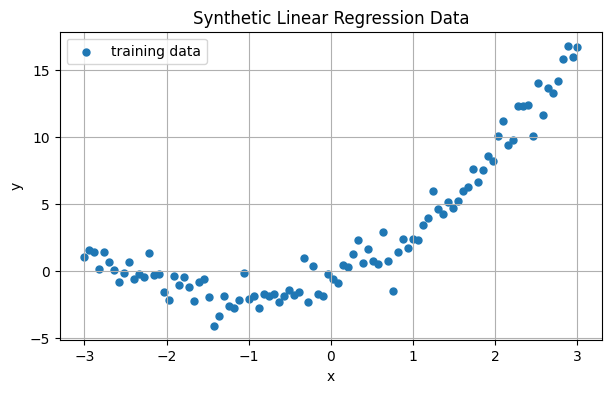

In [ ]:
set_seed(1)
pyro.clear_param_store()

# True data-generating parameters.
true_w1 = 2.5
true_w2 = 1.2
true_b = -0.7
true_sigma = 1.0

# Training data. cange it
n_train = 100
X_train = torch.linspace(-3, 3, n_train).unsqueeze(-1)
y_train = true_w1 * X_train.squeeze(-1) + true_w2 * X_train.squeeze(-1)**2 + true_b + true_sigma * torch.randn(n_train)

X_train = X_train.to(device)
y_train = y_train.to(device)

# Test grid for posterior predictive visualization.
X_grid = torch.linspace(-3.5, 3.5, 200).unsqueeze(-1).to(device)

plt.figure(figsize=(7, 4))
plt.scatter(X_train.cpu().numpy(), y_train.cpu().numpy(), s=25, label="training data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Linear Regression Data")
plt.grid(True)
plt.legend()
plt.show()

## 4. Define the Pyro Model

A Pyro model is a Python function that describes the data-generating process.

Important Pyro ingredients:

- `pyro.sample(name, distribution)` creates a random variable.
- `obs=y` conditions a random variable on observed data.
- `pyro.plate` declares conditional independence across observations.

Here, `w`, `b`, and `sigma` are latent random variables. The observed data are the values of `y`.

In [ ]:
def bayesian_linear_regression_model(X, y=None):
    """Bayesian linear regression model.

    Parameters
    ----------
    X : torch.Tensor of shape [n, 1]
        Input features.
    y : torch.Tensor of shape [n], optional
        Observed response values. If y is None, the model generates predictions.
    """
    # Prior for slope. change prior
    w1 = pyro.sample("w1", dist.Normal(0.0, 10.0))
    w2 = pyro.sample("w2", dist.Normal(0.0, 10.0))

    # Prior for intercept.
    b = pyro.sample("b", dist.Normal(0.0, 10.0))

    # Prior for observation noise. LogNormal keeps sigma positive.
    sigma = pyro.sample("sigma", dist.LogNormal(0.0, 1.0))

    # Mean of the Normal likelihood.
    mean = w1 * X.squeeze(-1) + w2 * X.squeeze(-1)**2 + b

    # Each observation is conditionally independent given w, b, and sigma.
    with pyro.plate("data", X.shape[0]):
        pyro.sample("obs", dist.Normal(mean, sigma), obs=y) #ASK

    return mean

## 5. Variational Guide and SVI

For most nontrivial Bayesian models, the exact posterior distribution is not available in closed form.

Pyro lets us use an **automatic guide**. Here we use `AutoDiagonalNormal`, which approximates the posterior with a multivariate Normal distribution whose covariance matrix is diagonal.

This is a practical and common starting point for variational inference.

In [ ]:
pyro.clear_param_store()

# The guide is the approximate posterior family.
blr_guide = AutoDiagonalNormal(bayesian_linear_regression_model)

# Adam optimizer used by Pyro's SVI routine.
blr_optimizer = Adam({"lr": 0.03})

# SVI object: model, guide, optimizer, and ELBO objective.
blr_svi = SVI(
    model=bayesian_linear_regression_model,
    guide=blr_guide,
    optim=blr_optimizer,
    loss=Trace_ELBO(),
)

## 6. Train the Bayesian Linear Regression Model

Each call to `svi.step(X_train, y_train)` performs one stochastic variational inference update.

The value returned is the negative ELBO. Smaller is better.

Step    1 | Negative ELBO = 38234.69
Step  500 | Negative ELBO = 2272.44
Step 1000 | Negative ELBO = 1495.35
Step 1500 | Negative ELBO = 1475.78
Step 2000 | Negative ELBO = 1471.51
Step 2500 | Negative ELBO = 1468.22


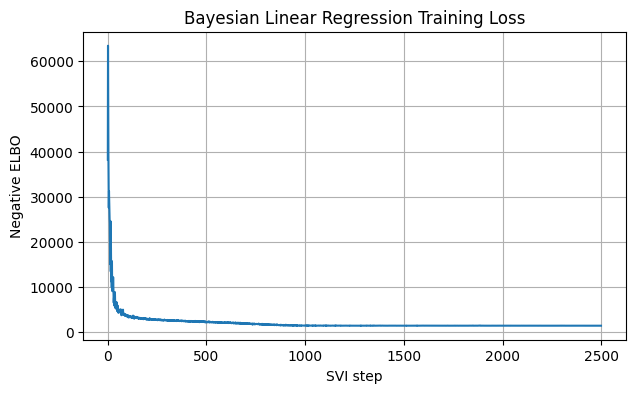

In [ ]:
num_steps = 2500
losses = []

for step in range(num_steps):
    loss = blr_svi.step(X_train, y_train)
    losses.append(loss)

    if (step + 1) % 500 == 0 or step == 0:
        print(f"Step {step + 1:4d} | Negative ELBO = {loss:.2f}")

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("SVI step")
plt.ylabel("Negative ELBO")
plt.title("Bayesian Linear Regression Training Loss")
plt.grid(True)
plt.show()

## 7. Inspect the Approximate Posterior

The guide can return posterior samples for the latent variables. We will draw samples of \(w\), \(b\), and \(\sigma\).

One posterior sample:
    w1:  2.4982
    w2:  1.1827
     b: -0.6247
 sigma:  1.0939
    w1: posterior mean =  2.497, posterior std =  0.018


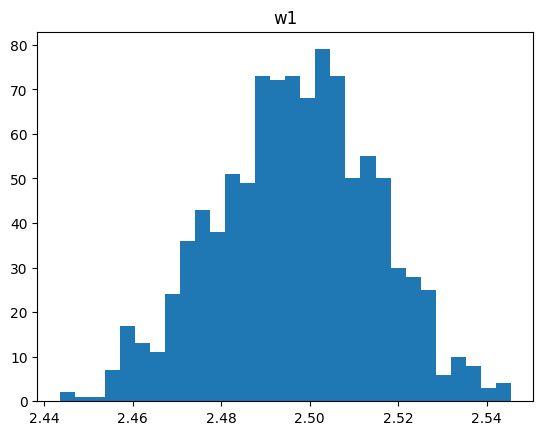

    w2: posterior mean =  1.189, posterior std =  0.012


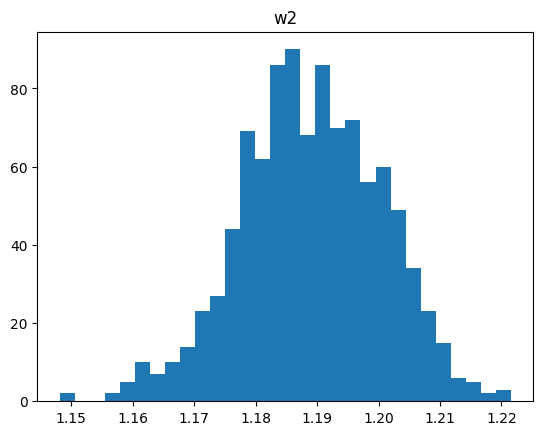

     b: posterior mean = -0.642, posterior std =  0.031


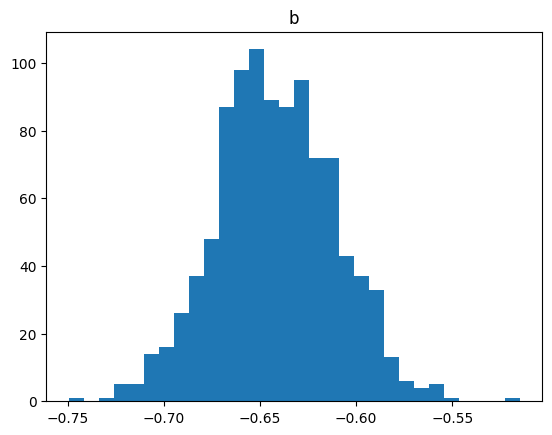

 sigma: posterior mean =  1.032, posterior std =  0.047


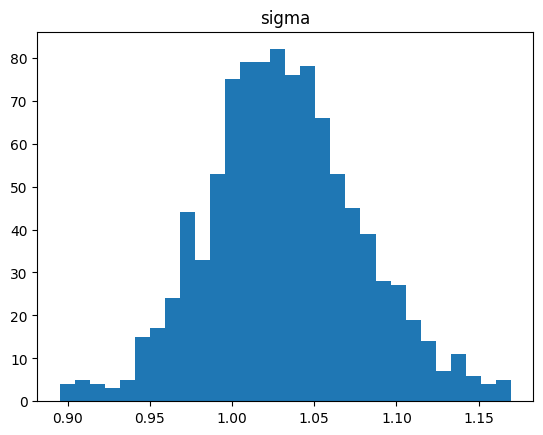


True values:
w1     = 2.5
w1     = 1.2
b     = -0.7
sigma = 1.0


In [ ]:
# Draw posterior samples from the trained guide.
posterior_samples = blr_guide(X_train, y_train)
print("One posterior sample:")
for name, value in posterior_samples.items():
    print(f"{name:>6s}: {value.detach().cpu().item(): .4f}")

# Use Predictive to draw many samples from the approximate posterior.
blr_predictive_for_latents = Predictive(
    bayesian_linear_regression_model,
    guide=blr_guide,
    num_samples=1000,
    return_sites=("w1","w2", "b", "sigma"),
)
latent_samples = blr_predictive_for_latents(X_train, y_train)

for name in ["w1","w2", "b", "sigma"]:
    values = latent_samples[name].detach().cpu().numpy().reshape(-1)
    print(
        f"{name:>6s}: posterior mean = {values.mean(): .3f}, "
        f"posterior std = {values.std(): .3f}"
    )
    plt.figure()
    plt.hist(values,bins=30)
    plt.title(name)
    plt.show()



print("\nTrue values:")
print("w1     =", true_w1)
print("w1     =", true_w2)
print("b     =", true_b)
print("sigma =", true_sigma)

## 8. Posterior Predictive Distribution

A Bayesian model does not produce just one fitted line. It produces a distribution over possible fitted lines and predictions.

We use `Predictive` to sample from the posterior predictive distribution on a grid of input points.

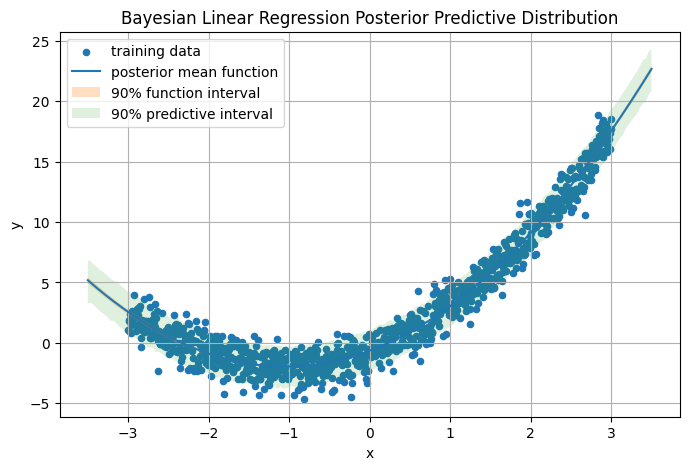

In [ ]:
blr_predictive = Predictive(
    bayesian_linear_regression_model,
    guide=blr_guide,
    num_samples=1000,
    return_sites=("obs", "_RETURN"),
)

with torch.no_grad():
    pred = blr_predictive(X_grid, None)

# obs samples include observation noise.
y_pred_samples = pred["obs"].detach().cpu().numpy()

# Return samples are the mean regression function without observation noise.
mean_function_samples = pred["_RETURN"].detach().cpu().numpy()

x_grid_np = X_grid.squeeze(-1).detach().cpu().numpy()

pred_mean = y_pred_samples.mean(axis=0)
pred_low = np.percentile(y_pred_samples, 5, axis=0)
pred_high = np.percentile(y_pred_samples, 95, axis=0)

func_mean = mean_function_samples.mean(axis=0)
func_low = np.percentile(mean_function_samples, 5, axis=0)
func_high = np.percentile(mean_function_samples, 95, axis=0)

plt.figure(figsize=(8, 5))
plt.scatter(X_train.cpu().numpy(), y_train.cpu().numpy(), s=20, label="training data")
plt.plot(x_grid_np, func_mean, label="posterior mean function")
plt.fill_between(x_grid_np, func_low, func_high, alpha=0.25, label="90% function interval")
plt.fill_between(x_grid_np, pred_low, pred_high, alpha=0.15, label="90% predictive interval")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Bayesian Linear Regression Posterior Predictive Distribution")
plt.grid(True)
plt.legend()
plt.show()

# Part II: Bayesian CNN for MNIST

## 9. CNN Classification Setup

MNIST contains grayscale images of handwritten digits. Each image has shape \(1 \times 28 \times 28\), and the label is one of 10 classes.

A conventional CNN learns fixed convolutional filters. A Bayesian CNN places probability distributions over the filters and dense-layer weights.

In this example, we use a very small CNN:

1. Bayesian convolution layer from 1 channel to 4 channels.
2. ReLU and max pooling.
3. Bayesian convolution layer from 4 channels to 8 channels.
4. ReLU and max pooling.
5. Bayesian fully connected hidden layer.
6. Bayesian output layer for 10 digit classes.

Because the CNN weights are random variables, prediction is performed by sampling multiple networks from the posterior and averaging their predicted probabilities.

## 10. Load MNIST

The next cell downloads MNIST using `torchvision`. To keep the Bayesian CNN example fast, we use small subsets by default.

You can increase `train_subset_size`, `test_subset_size`, `num_epochs`, or `max_batches_per_epoch` if you want a more serious experiment.

In [ ]:
if not TORCHVISION_AVAILABLE:
    raise ImportError("torchvision is required for the MNIST example.")

set_seed(123)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train_full = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

mnist_test_full = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_subset_size = 2000
test_subset_size = 300

train_indices = torch.randperm(len(mnist_train_full))[:train_subset_size]
test_indices = torch.randperm(len(mnist_test_full))[:test_subset_size]

mnist_train = Subset(mnist_train_full, train_indices)
mnist_test = Subset(mnist_test_full, test_indices)

batch_size = 64
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

print("Training subset size:", len(mnist_train))
print("Testing subset size:", len(mnist_test))

Training subset size: 2000
Testing subset size: 300


## 11. Visualize a Few MNIST Images

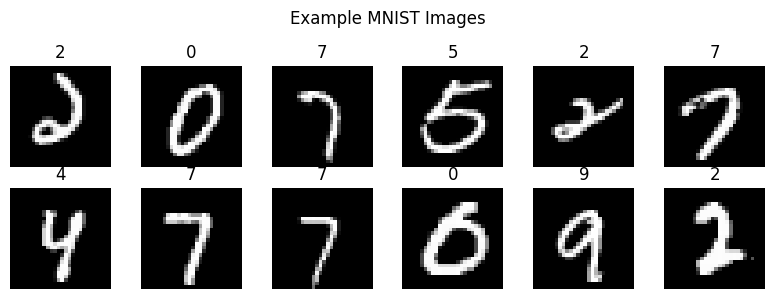

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(8, 3))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(images[i, 0], cmap="gray")
    plt.title(str(labels[i].item()))
    plt.axis("off")
plt.suptitle("Example MNIST Images")
plt.tight_layout()
plt.show()

## 12. Define a Bayesian CNN with PyroModule and PyroSample

`PyroModule` allows a PyTorch module to contain random parameters.

`PyroSample` replaces a deterministic parameter, such as a weight tensor, with a prior distribution. During inference, Pyro learns an approximate posterior over these random tensors.

The model below uses:

- Normal priors for convolution and dense weights.
- Categorical likelihood for class labels.
- Logits returned by the CNN.

The final likelihood is

$$
y_i \mid x_i, \theta \sim \text{Categorical}(\text{logits}=f_\theta(x_i)),
$$

where $\theta$ represents all Bayesian weights and biases.

In [ ]:
class BayesianSmallCNN(PyroModule):
    def __init__(self, prior_scale=0.10):
        super().__init__()

        self.conv1 = PyroModule[nn.Conv2d](1, 4, kernel_size=5, padding=2)
        self.conv1.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([4, 1, 5, 5]).to_event(4)
        )
        self.conv1.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([4]).to_event(1)
        )

        self.conv2 = PyroModule[nn.Conv2d](4, 8, kernel_size=5, padding=2)
        self.conv2.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([8, 4, 5, 5]).to_event(4)
        )
        self.conv2.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([8]).to_event(1)
        )

        flattened_dim = 8 * 7 * 7

        self.fc1 = PyroModule[nn.Linear](flattened_dim, 32)
        self.fc1.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([32, flattened_dim]).to_event(2)
        )
        self.fc1.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([32]).to_event(1)
        )

        self.fc2 = PyroModule[nn.Linear](32, 10)
        self.fc2.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([10, 32]).to_event(2)
        )
        self.fc2.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([10]).to_event(1)
        )

    def forward(self, x, y=None, dataset_size=None):
        x = F.tanh(self.conv1(x))
        x = F.max_pool2d(x, kernel_size=2)

        x = F.tanh(self.conv2(x))
        x = F.max_pool2d(x, kernel_size=2)

        x = torch.flatten(x, start_dim=1)
        x = F.tanh(self.fc1(x))
        logits = self.fc2(x)

        if y is not None and dataset_size is not None:
            scale = dataset_size / x.shape[0]
        else:
            scale = 1.0

        with pyro.plate("data", x.shape[0]):
            with pyro.poutine.scale(scale=scale):
                pyro.sample("obs", dist.Categorical(logits=logits), obs=y)

        return logits

## 13. Create the Guide and SVI Object

We again use `AutoDiagonalNormal`. For a Bayesian CNN, this means Pyro creates a diagonal Normal variational posterior over all Bayesian weights and biases.

This is not the only possible guide, but it is a clear starting point for teaching and experimentation.

In [ ]:
pyro.clear_param_store()
set_seed(72)

bcnn = BayesianSmallCNN(prior_scale=1.0).to(device)
bcnn_guide = AutoDiagonalNormal(bcnn)

bcnn_optimizer = Adam({"lr": 1e-3,"betas": (0.9, 0.999)})
bcnn_svi = SVI(
    model=bcnn,
    guide=bcnn_guide,
    optim=bcnn_optimizer,
    loss=Trace_ELBO(),
)

## 14. Training and Evaluation Utilities

The training loop is similar to ordinary PyTorch, except the optimization step is `svi.step(images, labels)` rather than `loss.backward()` followed by `optimizer.step()`.

For prediction, we sample several networks from the approximate posterior and average their softmax probabilities.

In [ ]:
def train_one_epoch_svi(svi, data_loader, device, dataset_size, max_batches=None):
    total_loss = 0.0
    total_examples = 0

    for batch_idx, (x, y) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)

        loss = svi.step(x, y, dataset_size)
        total_loss += loss
        total_examples += x.shape[0]

    return total_loss / max(1, total_examples)

@torch.no_grad()
def predict_proba_bayesian(model, guide, x, num_samples=20):
    """Average class probabilities over posterior samples of the network."""
    predictive = Predictive(
        model,
        guide=guide,
        num_samples=num_samples,
        return_sites=("_RETURN",),
    )
    out = predictive(x, None)

    # Shape is usually [num_samples, batch_size, num_classes].
    logits_samples = out["_RETURN"]
    probs_samples = torch.softmax(logits_samples, dim=-1)
    mean_probs = probs_samples.mean(dim=0)
    return mean_probs


@torch.no_grad()
def evaluate_bayesian_classifier(model, guide, data_loader, device, num_samples=20, max_batches=None):
    """Evaluate posterior-averaged classification accuracy."""
    correct = 0
    total = 0

    for batch_idx, (x, y) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)
        mean_probs = predict_proba_bayesian(model, guide, x, num_samples=num_samples)
        preds = mean_probs.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.numel()

    return correct / max(1, total)

## 15. Train the Bayesian CNN

This cell uses conservative defaults so it can run on a laptop. For better performance, try increasing:

- `train_subset_size`
- `num_epochs`
- `max_batches_per_epoch`
- `num_prediction_samples`

Fully Bayesian CNNs are much slower than deterministic CNNs because each prediction can require many posterior samples.

Epoch  1/100 | avg negative ELBO per example = 507.42 | approx test accuracy = 0.227
Epoch  2/100 | avg negative ELBO per example = 485.20 | approx test accuracy = 0.337
Epoch  3/100 | avg negative ELBO per example = 472.04 | approx test accuracy = 0.400
Epoch  4/100 | avg negative ELBO per example = 466.64 | approx test accuracy = 0.450
Epoch  5/100 | avg negative ELBO per example = 457.43 | approx test accuracy = 0.550
Epoch  6/100 | avg negative ELBO per example = 451.42 | approx test accuracy = 0.593
Epoch  7/100 | avg negative ELBO per example = 446.06 | approx test accuracy = 0.567
Epoch  8/100 | avg negative ELBO per example = 440.00 | approx test accuracy = 0.620
Epoch  9/100 | avg negative ELBO per example = 435.50 | approx test accuracy = 0.640
Epoch 10/100 | avg negative ELBO per example = 429.50 | approx test accuracy = 0.673
Epoch 11/100 | avg negative ELBO per example = 424.29 | approx test accuracy = 0.680
Epoch 12/100 | avg negative ELBO per example = 420.30 | approx te

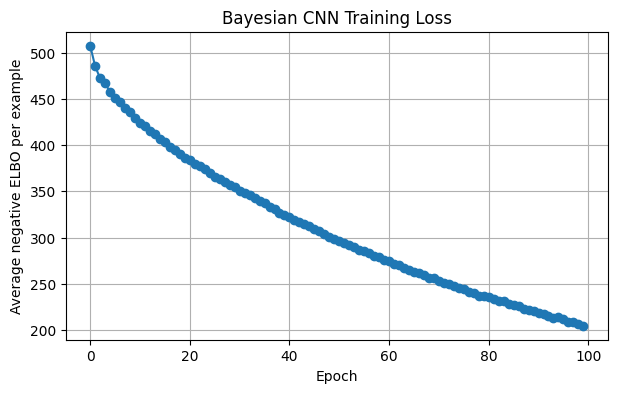

In [ ]:
num_epochs = 100
max_batches_per_epoch = None
num_prediction_samples = 10

bcnn_losses = []

for epoch in range(num_epochs):
    avg_loss = train_one_epoch_svi(
    bcnn_svi,
    train_loader,
    device,
    dataset_size=len(mnist_train),
    max_batches=max_batches_per_epoch,
)
    bcnn_losses.append(avg_loss)

    test_acc = evaluate_bayesian_classifier(
        bcnn,
        bcnn_guide,
        test_loader,
        device,
        num_samples=num_prediction_samples,
        max_batches=5,
    )

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"avg negative ELBO per example = {avg_loss:.2f} | "
        f"approx test accuracy = {test_acc:.3f}"
    )

plt.figure(figsize=(7, 4))
plt.plot(bcnn_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average negative ELBO per example")
plt.title("Bayesian CNN Training Loss")
plt.grid(True)
plt.show()

## 16. Visualize Bayesian CNN Predictions

The predicted class is obtained by averaging softmax probabilities over posterior samples.

The maximum averaged probability gives a simple uncertainty summary:

- High value: the posterior ensemble mostly agrees.
- Low value: the posterior ensemble is less confident.

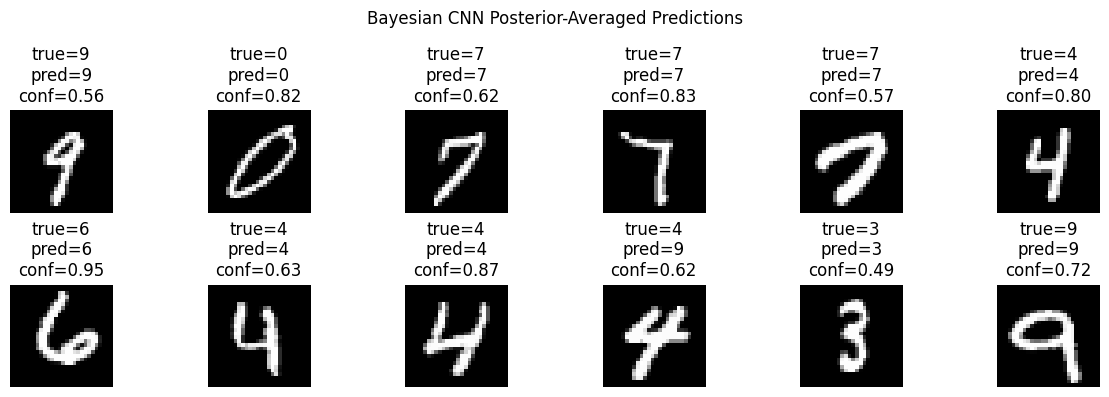

In [ ]:
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    mean_probs = predict_proba_bayesian(
        bcnn,
        bcnn_guide,
        images[:12],
        num_samples=30,
    )
    pred_labels = mean_probs.argmax(dim=-1)
    confidences = mean_probs.max(dim=-1).values

plt.figure(figsize=(12, 4))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(images[i, 0].detach().cpu().numpy(), cmap="gray")
    plt.title(
        f"true={labels[i].item()}\n"
        f"pred={pred_labels[i].item()}\n"
        f"conf={confidences[i].item():.2f}"
    )
    plt.axis("off")
plt.suptitle("Bayesian CNN Posterior-Averaged Predictions")
plt.tight_layout()
plt.show()

## 17. Class Probability Bar Plot for One Image

A Bayesian classifier gives a distribution over model weights. After averaging over posterior samples, we get posterior-averaged class probabilities.

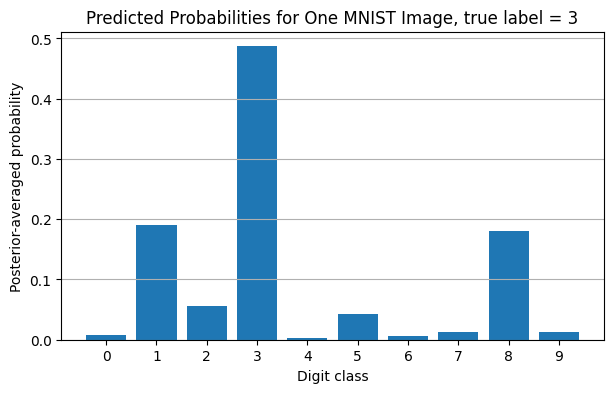

In [ ]:
example_index = 10
probs = mean_probs[example_index].detach().cpu().numpy()

plt.figure(figsize=(7, 4))
plt.bar(np.arange(10), probs)
plt.xticks(np.arange(10))
plt.xlabel("Digit class")
plt.ylabel("Posterior-averaged probability")
plt.title(f"Predicted Probabilities for One MNIST Image, true label = {labels[example_index].item()}")
plt.grid(True, axis="y")
plt.show()

## 18. Optional: Compare With a Deterministic CNN

This optional section gives a standard PyTorch CNN with the same architecture. It is useful for comparison because deterministic CNN training is usually much faster than Bayesian CNN training.

Unlike the Bayesian CNN, this model learns a single point estimate for each parameter.

In [ ]:
class DeterministicSmallCNN(nn.Module):
    """A deterministic CNN with the same architecture as the Bayesian CNN."""

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=5, padding=2)
        self.fc1 = nn.Linear(8 * 7 * 7, 32)
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        logits = self.fc2(x)
        return logits

In [ ]:
# Optional deterministic training example.
# Uncomment to run.

det_model = DeterministicSmallCNN().to(device)
det_optimizer = torch.optim.Adam(det_model.parameters(), lr=1e-3,betas=(0.9,0.999))
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    det_model.train()
    total_loss = 0.0
    total_examples = 0
    for batch_idx, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device)

        det_optimizer.zero_grad()
        logits = det_model(x)
        loss = criterion(logits, y)
        loss.backward()
        det_optimizer.step()

        total_loss += loss.item() * x.shape[0]
        total_examples += x.shape[0]

    print(f"Epoch {epoch + 1}: deterministic avg CE loss = {total_loss / total_examples:.3f}")

Epoch 1: deterministic avg CE loss = 2.031
Epoch 2: deterministic avg CE loss = 0.973
Epoch 3: deterministic avg CE loss = 0.540
Epoch 4: deterministic avg CE loss = 0.398
Epoch 5: deterministic avg CE loss = 0.321
Epoch 6: deterministic avg CE loss = 0.260
Epoch 7: deterministic avg CE loss = 0.236
Epoch 8: deterministic avg CE loss = 0.198
Epoch 9: deterministic avg CE loss = 0.179
Epoch 10: deterministic avg CE loss = 0.161
Epoch 11: deterministic avg CE loss = 0.135
Epoch 12: deterministic avg CE loss = 0.134
Epoch 13: deterministic avg CE loss = 0.121
Epoch 14: deterministic avg CE loss = 0.100
Epoch 15: deterministic avg CE loss = 0.095
Epoch 16: deterministic avg CE loss = 0.085
Epoch 17: deterministic avg CE loss = 0.088
Epoch 18: deterministic avg CE loss = 0.075
Epoch 19: deterministic avg CE loss = 0.060
Epoch 20: deterministic avg CE loss = 0.055


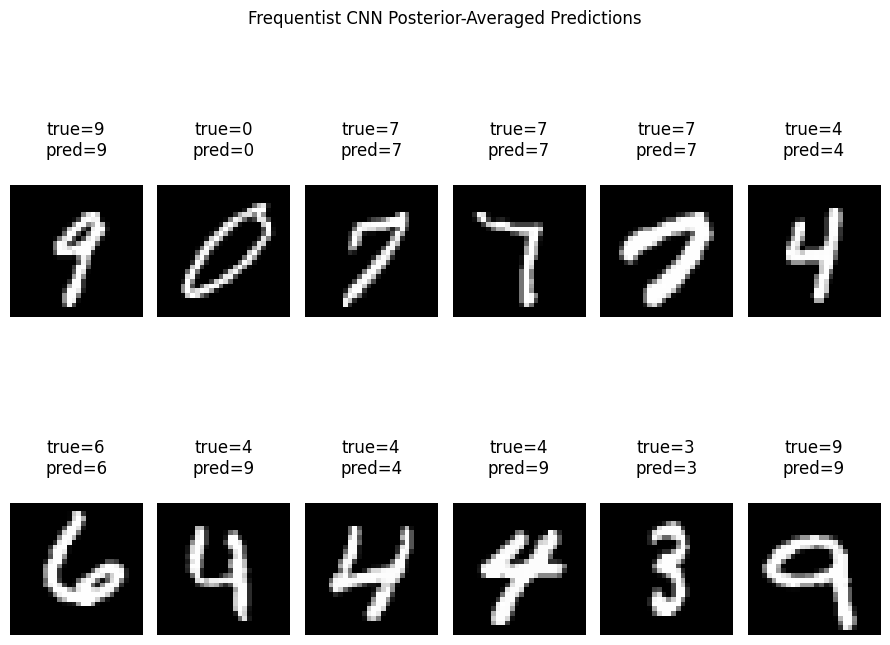

In [ ]:
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    det_pred =         logits = det_model(images[:12])
    # print(det_pred)
    pred_labels = det_pred.argmax(dim=-1)

plt.figure(figsize=(9, 8))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(images[i, 0].detach().cpu().numpy(), cmap="gray")
    plt.title(
        f"true={labels[i].item()}\n"
        f"pred={pred_labels[i].item()}\n"
    )
    plt.axis("off")
plt.suptitle("Frequentist CNN Posterior-Averaged Predictions")
plt.tight_layout()
plt.show()

# 19. Summary

In this notebook, we implemented two Pyro-based Bayesian models:

1. **Bayesian linear regression**
   - Priors on slope, intercept, and noise.
   - SVI with an automatic diagonal Normal guide.
   - Posterior predictive uncertainty intervals.

2. **Bayesian CNN for MNIST**
   - Priors on convolutional and dense weights.
   - Categorical likelihood for digit classification.
   - Posterior-averaged predictions.
   - Simple confidence estimates from averaged class probabilities.

Key ideas:

- Bayesian models represent uncertainty in parameters.
- Pyro models use `pyro.sample` to define random variables.
- Guides approximate the posterior distribution.
- SVI trains the guide by optimizing the ELBO.
- Prediction averages over posterior samples rather than relying on a single set of weights.

For a larger MNIST experiment, increase the subset size and number of epochs. For faster experimentation, make only the final layer Bayesian while keeping earlier convolutional layers deterministic.